# Movie Recommendation System

**Project Overview**

This notebook builds a movie recommendation system using the MovieLens-style dataset.

Steps covered:
1. Load dataset and perform Exploratory Data Analysis (EDA)
2. Clean and prepare metadata (genres, overview/tags)
3. Build a **content-based recommender** (TF-IDF text features + cosine similarity)
4. Build an optional **collaborative filtering** recommender (user-item ratings matrix)
5. Evaluate recommendations qualitatively with sample queries
6. (Optional) Package the recommender as a simple Flask API

If you have the MovieLens dataset (`movies.csv` and `ratings.csv` from
https://grouplens.org/datasets/movielens/, e.g. the "ml-latest-small" set),
place them in the same folder as this notebook. If they are not found, the
notebook falls back to a small built-in sample dataset so every cell still runs
end to end.


In [1]:
# 1. Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

pd.set_option("display.max_colwidth", 100)


## 1. Load Dataset

Tries to load the real MovieLens `movies.csv` / `ratings.csv` files. If they
are not present, a small embedded sample dataset is generated instead so the
notebook is fully self-contained and runnable.


In [2]:
MOVIES_PATH = "movies.csv"
RATINGS_PATH = "ratings.csv"

def load_sample_data():
    """A small built-in sample dataset (used if MovieLens files are absent)."""
    movies_data = [
        (1, "Toy Story (1995)", "Adventure|Animation|Children|Comedy|Fantasy",
         "A cowboy doll is threatened when a new spaceman action figure supplants him as top toy."),
        (2, "Jumanji (1995)", "Adventure|Children|Fantasy",
         "Two kids release a magical board game that unleashes jungle hazards into the real world."),
        (3, "Heat (1995)", "Action|Crime|Thriller",
         "A group of professional bank robbers start to feel the heat from the police."),
        (4, "GoldenEye (1995)", "Action|Adventure|Thriller",
         "James Bond investigates a satellite weapon while confronting a rogue agent."),
        (5, "The Lion King (1994)", "Animation|Children|Drama|Musical",
         "A young lion prince flees his kingdom after his father's death and must reclaim his throne."),
        (6, "Pulp Fiction (1994)", "Comedy|Crime|Drama|Thriller",
         "The lives of two mob hitmen, a boxer and a gangster's wife intertwine in violent, comic events."),
        (7, "Forrest Gump (1994)", "Comedy|Drama|Romance",
         "A slow-witted but kind-hearted man witnesses and unwittingly influences key historical events."),
        (8, "Speed (1994)", "Action|Romance|Thriller",
         "A young police officer must keep a bus moving at above fifty miles per hour to prevent a bomb."),
        (9, "True Lies (1994)", "Action|Comedy|Romance|Thriller",
         "A secret agent must balance his double life as a spy and a mundane family man."),
        (10, "Star Wars: Episode IV (1977)", "Action|Adventure|Sci-Fi",
         "Luke Skywalker joins forces with a Jedi Knight to save the galaxy from the Empire."),
        (11, "Star Wars: Episode V (1980)", "Action|Adventure|Sci-Fi",
         "The rebels are on the run as the Empire launches a devastating attack against them."),
        (12, "Aliens (1986)", "Action|Adventure|Horror|Sci-Fi",
         "Ripley returns to the planet where her crew encountered the deadly aliens, this time with marines."),
        (13, "Terminator 2: Judgment Day (1991)", "Action|Sci-Fi",
         "A cyborg protects a young boy from a more advanced and deadly cyborg sent from the future."),
        (14, "Jurassic Park (1993)", "Action|Adventure|Sci-Fi|Thriller",
         "A theme park of cloned dinosaurs descends into chaos when the creatures escape containment."),
        (15, "The Matrix (1999)", "Action|Sci-Fi",
         "A hacker discovers reality is a simulation and joins a rebellion against machines."),
        (16, "Titanic (1997)", "Drama|Romance",
         "A young couple from different social classes fall in love aboard the ill-fated ship."),
        (17, "The Notebook (2004)", "Drama|Romance",
         "A poor young man and a rich young woman fall deeply in love, but their relationship is tested."),
        (18, "Notting Hill (1999)", "Comedy|Romance",
         "A famous actress falls in love with a humble bookshop owner in London."),
        (19, "Sleepless in Seattle (1993)", "Comedy|Drama|Romance",
         "A widower's son calls a radio talk show to find his father a new wife, sparking a long-distance romance."),
        (20, "Toy Story 2 (1999)", "Adventure|Animation|Children|Comedy|Fantasy",
         "A cowboy doll is stolen by a toy collector, sending his friends on a rescue mission."),
        (21, "Monsters, Inc. (2001)", "Animation|Children|Comedy|Fantasy",
         "Two monster employees must return a little girl to her home after she sneaks into their world."),
        (22, "Finding Nemo (2003)", "Adventure|Animation|Children|Comedy",
         "A clownfish searches the ocean for his missing son with the help of a forgetful blue tang."),
        (23, "The Dark Knight (2008)", "Action|Crime|Drama|Thriller",
         "Batman faces the Joker, a criminal mastermind who plunges Gotham into chaos."),
        (24, "Inception (2010)", "Action|Adventure|Sci-Fi|Thriller",
         "A thief who steals secrets through dream-sharing technology is given a chance at redemption."),
        (25, "Interstellar (2014)", "Adventure|Drama|Sci-Fi",
         "A team of explorers travel through a wormhole in space to ensure humanity's survival."),
    ]
    movies = pd.DataFrame(movies_data, columns=["movieId", "title", "genres", "overview"])

    rng = np.random.default_rng(42)
    users = range(1, 31)
    ratings_rows = []
    for user in users:
        n_ratings = rng.integers(5, 15)
        rated_movies = rng.choice(movies["movieId"], size=n_ratings, replace=False)
        for m in rated_movies:
            ratings_rows.append((user, m, float(rng.integers(1, 6))))
    ratings = pd.DataFrame(ratings_rows, columns=["userId", "movieId", "rating"])
    return movies, ratings


if os.path.exists(MOVIES_PATH):
    movies = pd.read_csv(MOVIES_PATH)
    # Fill an overview column if the real MovieLens file (no overview column) is used
    if "overview" not in movies.columns:
        movies["overview"] = ""
    ratings = pd.read_csv(RATINGS_PATH) if os.path.exists(RATINGS_PATH) else load_sample_data()[1]
    print("Loaded MovieLens files from disk.")
else:
    movies, ratings = load_sample_data()
    print("MovieLens files not found - using built-in sample dataset instead.")

print(movies.shape, ratings.shape)
movies.head()


MovieLens files not found - using built-in sample dataset instead.
(25, 4) (278, 3)


,movieId,title,genres,overview
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,A cowboy doll is threatened when a new spaceman action figure supplants him as top toy.
1,2,Jumanji (1995),Adventure|Children|Fantasy,Two kids release a magical board game that unleashes jungle hazards into the real world.
2,3,Heat (1995),Action|Crime|Thriller,A group of professional bank robbers start to feel the heat from the police.
3,4,GoldenEye (1995),Action|Adventure|Thriller,James Bond investigates a satellite weapon while confronting a rogue agent.
4,5,The Lion King (1994),Animation|Children|Drama|Musical,A young lion prince flees his kingdom after his father's death and must reclaim his throne.


## 2. Exploratory Data Analysis (EDA)

Basic checks: shape, missing values, ratings distribution, and the most
common genres.


In [3]:
print("Movies dataset info:")
movies.info()
print()
print("Missing values per column:")
print(movies.isna().sum())


Movies dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movieId   25 non-null     int64
 1   title     25 non-null     str  
 2   genres    25 non-null     str  
 3   overview  25 non-null     str  
dtypes: int64(1), str(3)
memory usage: 932.0 bytes

Missing values per column:
movieId     0
title       0
genres      0
overview    0
dtype: int64


Ratings summary:
count    278.000000
mean       3.043165
std        1.398145
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: rating, dtype: float64


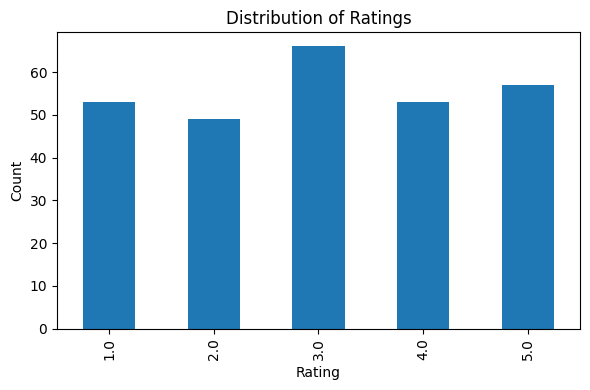

In [4]:
print("Ratings summary:")
print(ratings["rating"].describe())

plt.figure(figsize=(6, 4))
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


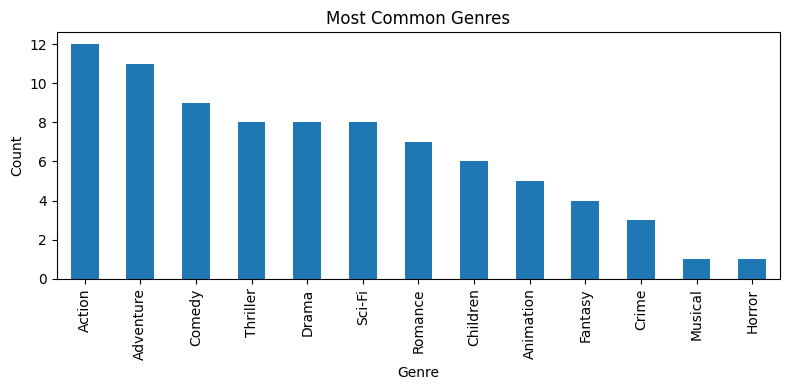

genres
Action       12
Adventure    11
Comedy        9
Thriller      8
Drama         8
Sci-Fi        8
Romance       7
Children      6
Animation     5
Fantasy       4
Crime         3
Musical       1
Horror        1
Name: count, dtype: int64

In [5]:
# Most common genres
genre_counts = (
    movies["genres"].str.split("|").explode().value_counts()
)

plt.figure(figsize=(8, 4))
genre_counts.head(15).plot(kind="bar")
plt.title("Most Common Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

genre_counts.head(15)


## 3. Metadata Cleaning

Combine `genres` and `overview` into a single text field ("tags") that will
be used to build TF-IDF features for the content-based recommender.


In [6]:
movies["genres_clean"] = movies["genres"].fillna("").str.replace("|", " ", regex=False)
movies["overview"] = movies["overview"].fillna("")
movies["tags"] = (movies["genres_clean"] + " " + movies["overview"]).str.lower()

# Drop duplicate titles / rows with empty tags, reset index for consistent similarity matrix lookups
movies = movies.drop_duplicates(subset="title").reset_index(drop=True)
movies = movies[movies["tags"].str.strip() != ""].reset_index(drop=True)

movies[["title", "tags"]].head()


,title,tags
0,Toy Story (1995),adventure animation children comedy fantasy a cowboy doll is threatened when a new spaceman acti...
1,Jumanji (1995),adventure children fantasy two kids release a magical board game that unleashes jungle hazards i...
2,Heat (1995),action crime thriller a group of professional bank robbers start to feel the heat from the police.
3,GoldenEye (1995),action adventure thriller james bond investigates a satellite weapon while confronting a rogue a...
4,The Lion King (1994),animation children drama musical a young lion prince flees his kingdom after his father's death ...


## 4. Content-Based Recommender (TF-IDF + Cosine Similarity)

We vectorize the `tags` field with TF-IDF and compute pairwise cosine
similarity between all movies. Given a movie title, we return the most
similar movies by cosine similarity score.


In [7]:
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies["tags"])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Cosine similarity matrix shape:", cosine_sim.shape)


TF-IDF matrix shape: (25, 211)
Cosine similarity matrix shape: (25, 25)


In [8]:
title_to_index = pd.Series(movies.index, index=movies["title"]).drop_duplicates()

def recommend_content_based(title, top_n=5):
    """Return the top_n movies most similar to the given title."""
    if title not in title_to_index:
        matches = movies[movies["title"].str.contains(title, case=False, regex=False)]
        if matches.empty:
            return f"'{title}' not found in the dataset."
        title = matches.iloc[0]["title"]

    idx = title_to_index[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != idx][:top_n]

    movie_indices = [i for i, _ in sim_scores]
    scores = [round(s, 3) for _, s in sim_scores]

    result = movies.iloc[movie_indices][["title", "genres"]].copy()
    result["similarity"] = scores
    return result.reset_index(drop=True)

recommend_content_based("Toy Story (1995)")


,title,genres,similarity
0,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.443
1,"Monsters, Inc. (2001)",Animation|Children|Comedy|Fantasy,0.186
2,Finding Nemo (2003),Adventure|Animation|Children|Comedy,0.148
3,Jumanji (1995),Adventure|Children|Fantasy,0.120
4,Sleepless in Seattle (1993),Comedy|Drama|Romance,0.101


## 5. Qualitative Evaluation - Sample Queries

We run the content-based recommender on a few sample movies and inspect the
results to sanity-check that recommendations make thematic sense.


In [9]:
sample_titles = [
    "Toy Story (1995)",
    "The Matrix (1999)",
    "Titanic (1997)",
    "The Dark Knight (2008)",
]

for t in sample_titles:
    print(f"Recommendations for: {t}")
    display(recommend_content_based(t, top_n=5))
    print("-" * 60)


Recommendations for: Toy Story (1995)


,title,genres,similarity
0,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.443
1,"Monsters, Inc. (2001)",Animation|Children|Comedy|Fantasy,0.186
2,Finding Nemo (2003),Adventure|Animation|Children|Comedy,0.148
3,Jumanji (1995),Adventure|Children|Fantasy,0.120
4,Sleepless in Seattle (1993),Comedy|Drama|Romance,0.101


------------------------------------------------------------
Recommendations for: The Matrix (1999)


,title,genres,similarity
0,Star Wars: Episode IV (1977),Action|Adventure|Sci-Fi,0.193
1,Star Wars: Episode V (1980),Action|Adventure|Sci-Fi,0.120
2,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.099
3,Inception (2010),Action|Adventure|Sci-Fi|Thriller,0.098
4,Aliens (1986),Action|Adventure|Horror|Sci-Fi,0.096


------------------------------------------------------------
Recommendations for: Titanic (1997)


,title,genres,similarity
0,The Notebook (2004),Drama|Romance,0.291
1,Notting Hill (1999),Comedy|Romance,0.109
2,Sleepless in Seattle (1993),Comedy|Drama|Romance,0.095
3,Speed (1994),Action|Romance|Thriller,0.086
4,The Lion King (1994),Animation|Children|Drama|Musical,0.077


------------------------------------------------------------
Recommendations for: The Dark Knight (2008)


,title,genres,similarity
0,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.136
1,Heat (1995),Action|Crime|Thriller,0.130
2,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,0.129
3,GoldenEye (1995),Action|Adventure|Thriller,0.060
4,Speed (1994),Action|Romance|Thriller,0.058


------------------------------------------------------------


## 6. (Optional) Collaborative Filtering

As an alternative/complement to the content-based approach, we build a simple
collaborative filtering recommender using matrix factorization (Truncated
SVD) on the user-item ratings matrix. This captures patterns in user rating
behavior rather than movie metadata.


In [10]:
user_item_matrix = ratings.pivot_table(index="userId", columns="movieId", values="rating").fillna(0)
print("User-item matrix shape:", user_item_matrix.shape)

n_components = min(10, min(user_item_matrix.shape) - 1)
svd = TruncatedSVD(n_components=n_components, random_state=42)
latent_matrix = svd.fit_transform(user_item_matrix)

item_latent = svd.components_.T  # movieId embeddings
item_sim = cosine_similarity(item_latent)

movie_id_to_pos = {mid: i for i, mid in enumerate(user_item_matrix.columns)}
pos_to_movie_id = {i: mid for mid, i in movie_id_to_pos.items()}

def recommend_collaborative(movie_title, top_n=5):
    """Recommend movies similar to movie_title based on collaborative rating patterns."""
    matches = movies[movies["title"].str.contains(movie_title, case=False, regex=False)]
    if matches.empty:
        return f"'{movie_title}' not found."
    movie_id = matches.iloc[0]["movieId"]

    if movie_id not in movie_id_to_pos:
        return f"'{movie_title}' has no ratings in the ratings dataset."

    pos = movie_id_to_pos[movie_id]
    sim_scores = list(enumerate(item_sim[pos]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != pos][:top_n]

    rec_movie_ids = [pos_to_movie_id[i] for i, _ in sim_scores]
    scores = [round(s, 3) for _, s in sim_scores]

    result = movies[movies["movieId"].isin(rec_movie_ids)][["title", "genres"]].copy()
    result = result.set_index("movieId" if "movieId" in result.columns else result.index)
    result = movies[movies["movieId"].isin(rec_movie_ids)][["movieId", "title", "genres"]].copy()
    result["similarity"] = result["movieId"].map(dict(zip(rec_movie_ids, scores)))
    return result.drop(columns="movieId").sort_values("similarity", ascending=False).reset_index(drop=True)

recommend_collaborative("Toy Story (1995)")


User-item matrix shape: (30, 25)


,title,genres,similarity
0,Aliens (1986),Action|Adventure|Horror|Sci-Fi,0.431
1,Jumanji (1995),Adventure|Children|Fantasy,0.364
2,The Lion King (1994),Animation|Children|Drama|Musical,0.361
3,Titanic (1997),Drama|Romance,0.333
4,The Dark Knight (2008),Action|Crime|Drama|Thriller,0.325


## 7. (Optional) Package as a Simple Flask API

The cell below is provided as **reference code** (not executed in this
notebook) showing how the content-based recommender could be exposed as a
small Flask web service with a single `/recommend` endpoint.

To run it: save the cell contents to `app.py` and run `python app.py`, then
call, for example:

`GET http://127.0.0.1:5000/recommend?title=Toy Story (1995)&top_n=5`


In [11]:
# Reference implementation only - not executed in the notebook.
FLASK_APP_CODE = '''
from flask import Flask, request, jsonify
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

app = Flask(__name__)

# Load and prepare data once at startup
movies = pd.read_csv("movies.csv")
movies["genres_clean"] = movies["genres"].fillna("").str.replace("|", " ", regex=False)
movies["overview"] = movies.get("overview", "").fillna("")
movies["tags"] = (movies["genres_clean"] + " " + movies["overview"]).str.lower()

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies["tags"])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
title_to_index = pd.Series(movies.index, index=movies["title"]).drop_duplicates()


def recommend(title, top_n=5):
    if title not in title_to_index:
        matches = movies[movies["title"].str.contains(title, case=False, regex=False)]
        if matches.empty:
            return None
        title = matches.iloc[0]["title"]
    idx = title_to_index[title]
    sim_scores = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != idx][:top_n]
    return movies.iloc[[i for i, _ in sim_scores]][["title", "genres"]].to_dict(orient="records")


@app.route("/recommend", methods=["GET"])
def recommend_endpoint():
    title = request.args.get("title", "")
    top_n = int(request.args.get("top_n", 5))
    results = recommend(title, top_n)
    if results is None:
        return jsonify({"error": f"'{title}' not found"}), 404
    return jsonify({"query": title, "recommendations": results})


if __name__ == "__main__":
    app.run(debug=True)
'''

print(FLASK_APP_CODE)



from flask import Flask, request, jsonify
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

app = Flask(__name__)

# Load and prepare data once at startup
movies = pd.read_csv("movies.csv")
movies["genres_clean"] = movies["genres"].fillna("").str.replace("|", " ", regex=False)
movies["overview"] = movies.get("overview", "").fillna("")
movies["tags"] = (movies["genres_clean"] + " " + movies["overview"]).str.lower()

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies["tags"])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
title_to_index = pd.Series(movies.index, index=movies["title"]).drop_duplicates()


def recommend(title, top_n=5):
    if title not in title_to_index:
        matches = movies[movies["title"].str.contains(title, case=False, regex=False)]
        if matches.empty:
            return None
        title = matches.iloc[0]["title"]
    idx =

## Summary

- Loaded and explored movie metadata and ratings.
- Cleaned metadata into a unified `tags` field.
- Built a content-based recommender using TF-IDF and cosine similarity.
- Built an optional collaborative filtering recommender using matrix
  factorization (Truncated SVD) on the ratings matrix.
- Verified recommendations qualitatively with sample queries.
- Included reference code for packaging the recommender as a Flask API.
